# ADHD Classification Using a Functional-Connectivity GNN

Each patient is represented as a brain graph. EEG channels are graph nodes, while signal correlations describe functional connections between channels.

A Graph Neural Network learns spatial and frequency-related brain-network patterns associated with ADHD.

## 1. Setup

This notebook uses the previously generated Full and Simple preprocessed EEG datasets. No additional preprocessing of the original EEG recordings is required.

In [1]:
import copy
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Load the Preprocessed EEG

The Full and Simple datasets must contain the same epochs, patients and diagnostic labels.

In [2]:
full_files = list(
    Path("/kaggle/input").rglob(
        "eeg_dataset_full_zscore.pkl"
    )
)

simple_files = list(
    Path("/kaggle/input").rglob(
        "eeg_dataset_simple_zscore.pkl"
    )
)

assert len(full_files) == 1, (
    f"Full dataset problem: {full_files}"
)

assert len(simple_files) == 1, (
    f"Simple dataset problem: {simple_files}"
)

with open(full_files[0], "rb") as file:
    full_data = pickle.load(file)

with open(simple_files[0], "rb") as file:
    simple_data = pickle.load(file)

assert (
    full_data["epochs"].shape
    == simple_data["epochs"].shape
)

assert np.array_equal(
    full_data["labels"],
    simple_data["labels"]
)

assert np.array_equal(
    full_data["patient_ids"],
    simple_data["patient_ids"]
)

full_epochs = full_data["epochs"].astype(
    np.float32,
    copy=False
)

simple_epochs = simple_data["epochs"].astype(
    np.float32,
    copy=False
)

epoch_labels = full_data["labels"].astype(
    np.int64,
    copy=False
)

epoch_patient_ids = (
    full_data["patient_ids"]
    .astype(str)
)

channel_names = list(
    full_data["channel_names"]
)

SFREQ = 128.0

print("Full epochs:", full_epochs.shape)
print("Simple epochs:", simple_epochs.shape)
print("Channels:", channel_names)

Full epochs: (16749, 15, 256)
Simple epochs: (16749, 15, 256)
Channels: ['Fz', 'Cz', 'Pz', 'C3', 'C4', 'Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'P3', 'P4', 'O1', 'O2']


## 3. Construct Patient Brain Graphs

For every patient:

- Nodes represent EEG channels.
- Node features contain relative power in five frequency bands from both preprocessing views.
- Edge weights represent average absolute correlation between channels.
- Only the five strongest connections of each channel are retained.

In [3]:
FREQUENCY_BANDS = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 45)
}


def calculate_relative_band_power(
    epochs,
    sampling_rate=128.0
):
    """
    Input:
        epochs: epochs × channels × time

    Output:
        channels × frequency bands
    """

    n_times = epochs.shape[-1]

    window = np.hanning(
        n_times
    ).astype(np.float32)

    spectrum = np.fft.rfft(
        epochs * window[None, None, :],
        axis=-1
    )

    power = np.abs(spectrum) ** 2

    frequencies = np.fft.rfftfreq(
        n_times,
        d=1.0 / sampling_rate
    )

    total_mask = (
        (frequencies >= 1)
        & (frequencies <= 45)
    )

    total_power = (
        power[..., total_mask].sum(axis=-1)
        + 1e-8
    )

    band_features = []

    for low_frequency, high_frequency in (
        FREQUENCY_BANDS.values()
    ):
        band_mask = (
            (frequencies >= low_frequency)
            & (frequencies < high_frequency)
        )

        band_power = (
            power[..., band_mask].sum(axis=-1)
            / total_power
        )

        # Average across patient epochs.
        band_features.append(
            band_power.mean(axis=0)
        )

    return np.stack(
        band_features,
        axis=-1
    ).astype(np.float32)


def calculate_mean_absolute_correlation(epochs):
    """
    Calculates average channel correlation
    across all epochs belonging to one patient.
    """

    centered = (
        epochs
        - epochs.mean(
            axis=-1,
            keepdims=True
        )
    )

    norms = np.sqrt(
        np.sum(centered ** 2, axis=-1)
        + 1e-8
    )

    normalized = (
        centered
        / norms[..., None]
    )

    epoch_correlations = np.einsum(
        "ect,edt->ecd",
        normalized,
        normalized,
        optimize=True
    )

    connectivity = np.mean(
        np.abs(epoch_correlations),
        axis=0
    )

    return connectivity.astype(np.float32)


def create_sparse_normalized_graph(
    connectivity,
    top_k=5
):
    """
    Retains each channel's strongest edges
    and performs GCN normalization.
    """

    adjacency = connectivity.copy()
    np.fill_diagonal(adjacency, 0.0)

    n_channels = adjacency.shape[0]
    sparse_adjacency = np.zeros_like(adjacency)

    for channel_index in range(n_channels):
        strongest = np.argpartition(
            adjacency[channel_index],
            -top_k
        )[-top_k:]

        sparse_adjacency[
            channel_index,
            strongest
        ] = adjacency[
            channel_index,
            strongest
        ]

    # Make the graph undirected.
    sparse_adjacency = np.maximum(
        sparse_adjacency,
        sparse_adjacency.T
    )

    # Add self-connections.
    sparse_adjacency += np.eye(
        n_channels,
        dtype=np.float32
    )

    degree = sparse_adjacency.sum(axis=1)

    inverse_sqrt_degree = 1.0 / np.sqrt(
        degree + 1e-8
    )

    normalized_adjacency = (
        inverse_sqrt_degree[:, None]
        * sparse_adjacency
        * inverse_sqrt_degree[None, :]
    )

    return normalized_adjacency.astype(
        np.float32
    )

## 4. Extract One Graph per Patient

The Full and Simple connectivity matrices are averaged to reduce dependence on one preprocessing method.

Node features contain Full band power, Simple band power and the absolute difference between them.

In [4]:
patient_table = (
    pd.DataFrame({
        "patient_id": epoch_patient_ids,
        "label": epoch_labels
    })
    .drop_duplicates("patient_id")
    .reset_index(drop=True)
)

graph_patient_ids = (
    patient_table["patient_id"]
    .astype(str)
    .to_numpy()
)

graph_node_features = []
graph_adjacencies = []
graph_labels = []

for patient_number, patient_id in enumerate(
    graph_patient_ids,
    start=1
):
    indices = np.where(
        epoch_patient_ids == patient_id
    )[0]

    patient_full = full_epochs[indices]
    patient_simple = simple_epochs[indices]

    full_band_power = (
        calculate_relative_band_power(
            patient_full,
            SFREQ
        )
    )

    simple_band_power = (
        calculate_relative_band_power(
            patient_simple,
            SFREQ
        )
    )

    power_difference = np.abs(
        full_band_power
        - simple_band_power
    )

    # 5 Full + 5 Simple + 5 difference features.
    node_features = np.concatenate(
        [
            full_band_power,
            simple_band_power,
            power_difference
        ],
        axis=-1
    )

    full_connectivity = (
        calculate_mean_absolute_correlation(
            patient_full
        )
    )

    simple_connectivity = (
        calculate_mean_absolute_correlation(
            patient_simple
        )
    )

    consensus_connectivity = 0.5 * (
        full_connectivity
        + simple_connectivity
    )

    adjacency = (
        create_sparse_normalized_graph(
            consensus_connectivity,
            top_k=5
        )
    )

    graph_node_features.append(
        node_features
    )

    graph_adjacencies.append(
        adjacency
    )

    graph_labels.append(
        int(epoch_labels[indices[0]])
    )

    if (
        patient_number % 20 == 0
        or patient_number
        == len(graph_patient_ids)
    ):
        print(
            f"Processed "
            f"{patient_number}/"
            f"{len(graph_patient_ids)} patients"
        )

graph_node_features = np.stack(
    graph_node_features
).astype(np.float32)

graph_adjacencies = np.stack(
    graph_adjacencies
).astype(np.float32)

graph_labels = np.asarray(
    graph_labels,
    dtype=np.int64
)

print(
    "Node features:",
    graph_node_features.shape
)

print(
    "Adjacency matrices:",
    graph_adjacencies.shape
)

print(
    "Labels:",
    graph_labels.shape
)

Processed 20/121 patients
Processed 40/121 patients
Processed 60/121 patients
Processed 80/121 patients
Processed 100/121 patients
Processed 120/121 patients
Processed 121/121 patients
Node features: (121, 15, 15)
Adjacency matrices: (121, 15, 15)
Labels: (121,)


## 5. Save the Patient Graphs

Graph extraction is performed only once. The resulting graph dataset can be loaded directly if the notebook is restarted.

In [5]:
np.savez_compressed(
    "/kaggle/working/eeg_patient_graphs.npz",
    node_features=graph_node_features,
    adjacency=graph_adjacencies,
    labels=graph_labels,
    patient_ids=graph_patient_ids,
    channel_names=np.asarray(channel_names)
)

print(
    "Saved graph dataset to "
    "/kaggle/working/eeg_patient_graphs.npz"
)

Saved graph dataset to /kaggle/working/eeg_patient_graphs.npz


## 6. Patient-Level Split and Feature Standardization

Patients are divided into training, validation and test groups. Feature standardization is fitted only on training patients to prevent data leakage.

A channel-identity feature is also included so the GNN can distinguish electrodes such as frontal, central and posterior channels.

In [6]:
all_graph_indices = np.arange(
    len(graph_labels)
)

trainval_indices, test_indices = train_test_split(
    all_graph_indices,
    test_size=0.20,
    stratify=graph_labels,
    random_state=SEED
)

train_indices, val_indices = train_test_split(
    trainval_indices,
    test_size=0.20,
    stratify=graph_labels[trainval_indices],
    random_state=SEED
)

n_patients, n_channels, n_spectral_features = (
    graph_node_features.shape
)

# Fit only on nodes belonging to training patients.
feature_scaler = StandardScaler()

feature_scaler.fit(
    graph_node_features[train_indices].reshape(
        -1,
        n_spectral_features
    )
)

scaled_spectral_features = (
    feature_scaler.transform(
        graph_node_features.reshape(
            -1,
            n_spectral_features
        )
    )
    .reshape(
        n_patients,
        n_channels,
        n_spectral_features
    )
    .astype(np.float32)
)

# One-hot channel identity.
channel_identity = np.broadcast_to(
    np.eye(
        n_channels,
        dtype=np.float32
    )[None, :, :],
    (
        n_patients,
        n_channels,
        n_channels
    )
)

gnn_node_features = np.concatenate(
    [
        scaled_spectral_features,
        channel_identity
    ],
    axis=-1
).astype(np.float32)

print("Train patients:", len(train_indices))
print("Validation patients:", len(val_indices))
print("Test patients:", len(test_indices))

print(
    "Final node features:",
    gnn_node_features.shape
)

print(
    "Train labels:",
    np.bincount(graph_labels[train_indices])
)

print(
    "Validation labels:",
    np.bincount(graph_labels[val_indices])
)

print(
    "Test labels:",
    np.bincount(graph_labels[test_indices])
)

Train patients: 76
Validation patients: 20
Test patients: 25
Final node features: (121, 15, 30)
Train labels: [38 38]
Validation labels: [10 10]
Test labels: [12 13]


## 7. Graph Dataset

Every item contains one patient's node features, normalized connectivity matrix, diagnosis and patient identifier.

In [7]:
class PatientGraphDataset(Dataset):
    def __init__(self, patient_indices):
        self.patient_indices = np.asarray(
            patient_indices
        )

    def __len__(self):
        return len(self.patient_indices)

    def __getitem__(self, item):
        patient_index = self.patient_indices[item]

        node_features = torch.from_numpy(
            gnn_node_features[patient_index]
        )

        adjacency = torch.from_numpy(
            graph_adjacencies[patient_index]
        )

        label = torch.tensor(
            graph_labels[patient_index],
            dtype=torch.float32
        )

        patient_id = graph_patient_ids[
            patient_index
        ]

        return (
            node_features,
            adjacency,
            label,
            patient_id
        )


train_graph_dataset = PatientGraphDataset(
    train_indices
)

val_graph_dataset = PatientGraphDataset(
    val_indices
)

test_graph_dataset = PatientGraphDataset(
    test_indices
)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_graph_loader = DataLoader(
    train_graph_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    generator=loader_generator
)

val_graph_loader = DataLoader(
    val_graph_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_graph_loader = DataLoader(
    test_graph_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

sample_features, sample_graph, sample_label, sample_id = (
    train_graph_dataset[0]
)

print("Patient:", sample_id)
print("Node features:", sample_features.shape)
print("Adjacency:", sample_graph.shape)
print("Label:", int(sample_label.item()))

Patient: v114
Node features: torch.Size([15, 30])
Adjacency: torch.Size([15, 15])
Label: 0


## 8. Functional-Connectivity GNN

Graph-convolution layers exchange information between connected EEG channels. Node attention then learns which channels contribute most strongly to the patient-level prediction.

In [8]:
class DenseGraphConvolution(nn.Module):
    def __init__(
        self,
        input_features,
        output_features
    ):
        super().__init__()

        self.linear = nn.Linear(
            input_features,
            output_features
        )

    def forward(self, node_features, adjacency):
        aggregated_features = torch.bmm(
            adjacency,
            node_features
        )

        return self.linear(
            aggregated_features
        )


class FunctionalConnectivityGNN(nn.Module):
    def __init__(
        self,
        input_features,
        hidden_features=64,
        dropout=0.4
    ):
        super().__init__()

        self.graph_conv1 = DenseGraphConvolution(
            input_features,
            hidden_features
        )

        self.graph_conv2 = DenseGraphConvolution(
            hidden_features,
            hidden_features
        )

        self.graph_conv3 = DenseGraphConvolution(
            hidden_features,
            hidden_features
        )

        self.norm1 = nn.LayerNorm(
            hidden_features
        )

        self.norm2 = nn.LayerNorm(
            hidden_features
        )

        self.norm3 = nn.LayerNorm(
            hidden_features
        )

        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

        self.node_attention = nn.Sequential(
            nn.Linear(hidden_features, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_features, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, node_features, adjacency):
        h1 = self.graph_conv1(
            node_features,
            adjacency
        )

        h1 = self.activation(
            self.norm1(h1)
        )

        h1 = self.dropout(h1)

        h2 = self.graph_conv2(
            h1,
            adjacency
        )

        h2 = self.activation(
            self.norm2(h2)
        )

        # Residual connection.
        h2 = h1 + self.dropout(h2)

        h3 = self.graph_conv3(
            h2,
            adjacency
        )

        h3 = self.activation(
            self.norm3(h3)
        )

        h3 = h2 + self.dropout(h3)

        attention_scores = (
            self.node_attention(h3)
            .squeeze(-1)
        )

        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        patient_embedding = torch.sum(
            attention_weights.unsqueeze(-1)
            * h3,
            dim=1
        )

        logits = (
            self.classifier(
                patient_embedding
            )
            .squeeze(-1)
        )

        return logits, attention_weights


INPUT_FEATURES = gnn_node_features.shape[-1]

gnn_model = FunctionalConnectivityGNN(
    input_features=INPUT_FEATURES,
    hidden_features=64,
    dropout=0.4
).to(DEVICE)

print(gnn_model)

print(
    "Trainable parameters:",
    sum(
        parameter.numel()
        for parameter in gnn_model.parameters()
        if parameter.requires_grad
    )
)

FunctionalConnectivityGNN(
  (graph_conv1): DenseGraphConvolution(
    (linear): Linear(in_features=30, out_features=64, bias=True)
  )
  (graph_conv2): DenseGraphConvolution(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (graph_conv3): DenseGraphConvolution(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (activation): GELU(approximate='none')
  (dropout): Dropout(p=0.4, inplace=False)
  (node_attention): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_fe

## 9. Patient-Level Evaluation Functions

Performance is measured using patient probabilities rather than individual EEG epochs.

In [9]:
def graph_classification_metrics(
    y_true,
    probabilities,
    threshold=0.5
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "specificity":
            tn / max(tn + fp, 1),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),
        "mcc": matthews_corrcoef(
            y_true,
            predictions
        )
    }


@torch.no_grad()
def evaluate_graph_loader(
    model,
    loader,
    criterion
):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []
    all_patient_ids = []
    all_attention = []

    for (
        node_features,
        adjacency,
        labels,
        patient_ids
    ) in loader:

        node_features = node_features.to(DEVICE)
        adjacency = adjacency.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, attention = model(
            node_features,
            adjacency
        )

        loss = criterion(
            logits,
            labels
        )

        probabilities = torch.sigmoid(logits)

        total_loss += (
            loss.item() * len(labels)
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_patient_ids.extend(
            list(patient_ids)
        )

        all_attention.append(
            attention.cpu().numpy()
        )

    y_true = np.asarray(
        all_labels,
        dtype=int
    )

    probabilities = np.asarray(
        all_probabilities
    )

    attention = np.concatenate(
        all_attention,
        axis=0
    )

    metrics = graph_classification_metrics(
        y_true,
        probabilities
    )

    average_loss = (
        total_loss / len(y_true)
    )

    return (
        average_loss,
        metrics,
        y_true,
        probabilities,
        all_patient_ids,
        attention
    )

## 10. Train the GNN

The model is trained on patient graphs. Validation ROC-AUC determines early stopping, while validation loss resolves ties between epochs with equal AUC.

In [13]:
train_graph_labels = graph_labels[
    train_indices
]

n_control = np.sum(
    train_graph_labels == 0
)

n_adhd = np.sum(
    train_graph_labels == 1
)

positive_weight = torch.tensor(
    [n_control / max(n_adhd, 1)],
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.AdamW(
    gnn_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )
)

MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 20

best_val_auc = -np.inf
best_val_loss = np.inf
best_state = None
best_epoch = 0
epochs_without_improvement = 0

history = []

for epoch in range(1, MAX_EPOCHS + 1):
    gnn_model.train()
    running_loss = 0.0

    for (
        node_features,
        adjacency,
        labels,
        _
    ) in train_graph_loader:

        node_features = node_features.to(DEVICE)
        adjacency = adjacency.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits, _ = gnn_model(
            node_features,
            adjacency
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        nn.utils.clip_grad_norm_(
            gnn_model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += (
            loss.item() * len(labels)
        )

    train_loss = (
        running_loss
        / len(train_graph_dataset)
    )

    (
        val_loss,
        val_metrics,
        _,
        _,
        _,
        _
    ) = evaluate_graph_loader(
        gnn_model,
        val_graph_loader,
        criterion
    )

    val_auc = val_metrics["roc_auc"]
    scheduler.step(val_auc)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_accuracy":
            val_metrics["accuracy"]
    })

    better_auc = (
        val_auc > best_val_auc + 1e-4
    )

    equal_auc_better_loss = (
        abs(val_auc - best_val_auc) <= 1e-4
        and val_loss < best_val_loss - 1e-4
    )

    if better_auc or equal_auc_better_loss:
        best_val_auc = val_auc
        best_val_loss = val_loss
        best_epoch = epoch

        best_state = copy.deepcopy(
            gnn_model.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epoch == 1
        or epoch % 5 == 0
    ):
        print(
            f"Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val AUC {val_auc:.3f} | "
            f"val accuracy "
            f"{val_metrics['accuracy']:.3f}"
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print("Early stopping.")
        break

assert best_state is not None

gnn_model.load_state_dict(best_state)

history_df = pd.DataFrame(history)

print("Best epoch:", best_epoch)
print(
    f"Best validation ROC-AUC: "
    f"{best_val_auc:.3f}"
)

Epoch 001 | train loss 0.6181 | val loss 0.6182 | val AUC 0.760 | val accuracy 0.700
Epoch 005 | train loss 0.5670 | val loss 0.6180 | val AUC 0.690 | val accuracy 0.700
Epoch 010 | train loss 0.5522 | val loss 0.6162 | val AUC 0.700 | val accuracy 0.700
Epoch 015 | train loss 0.5701 | val loss 0.6188 | val AUC 0.700 | val accuracy 0.650
Epoch 020 | train loss 0.5475 | val loss 0.6156 | val AUC 0.710 | val accuracy 0.650
Early stopping.
Best epoch: 1
Best validation ROC-AUC: 0.760


## GNN Training Behaviour

The best validation ROC-AUC of 0.760 occurred during the first epoch. Afterward, training loss generally decreased, while validation loss remained nearly unchanged and validation ROC-AUC decreased to approximately 0.69–0.72.

This indicates that the GNN learned patterns specific to the training graphs without improving its generalization to validation patients. Early stopping consequently restored the first-epoch model.

## 11. Training History

The curves are used to inspect convergence and possible overfitting.

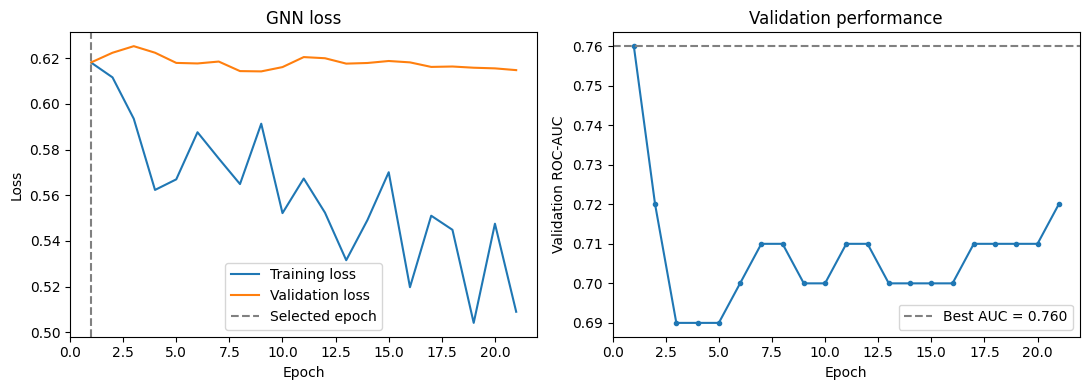

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training loss"
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

axes[0].axvline(
    best_epoch,
    linestyle="--",
    color="gray",
    label="Selected epoch"
)

axes[0].set_title("GNN loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["val_auc"],
    marker="o",
    markersize=3
)

axes[1].axhline(
    best_val_auc,
    linestyle="--",
    color="gray",
    label=f"Best AUC = {best_val_auc:.3f}"
)

axes[1].set_title(
    "Validation performance"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Evaluate Unseen Test Patients

The final graph model is evaluated on patients excluded from feature standardization, training and model selection.

In [15]:
(
    test_loss,
    test_metrics,
    y_test,
    test_probabilities,
    test_patient_ids,
    test_attention
) = evaluate_graph_loader(
    gnn_model,
    test_graph_loader,
    criterion
)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

gnn_metrics_df = pd.DataFrame(
    [test_metrics],
    index=["Functional-Connectivity GNN"]
)

display(gnn_metrics_df.round(3))

print("Test loss:", round(test_loss, 4))

,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,mcc
Functional-Connectivity GNN,0.4,0.397,0.429,0.462,0.333,0.444,0.34,-0.206


Test loss: 0.7558


## GNN Test Performance

The Functional-Connectivity GNN achieved 40% accuracy, 39.7% balanced accuracy and an ROC-AUC of 0.340. Its negative MCC of -0.206 indicates that its predictions had a negative relationship with the true test labels.

These results show that the extracted patient graphs did not provide a reliable separation between ADHD and Control patients.

## 13. Confusion Matrix and ROC Curve

The confusion matrix shows patient classification counts. The ROC curve evaluates discrimination without depending on a single threshold.

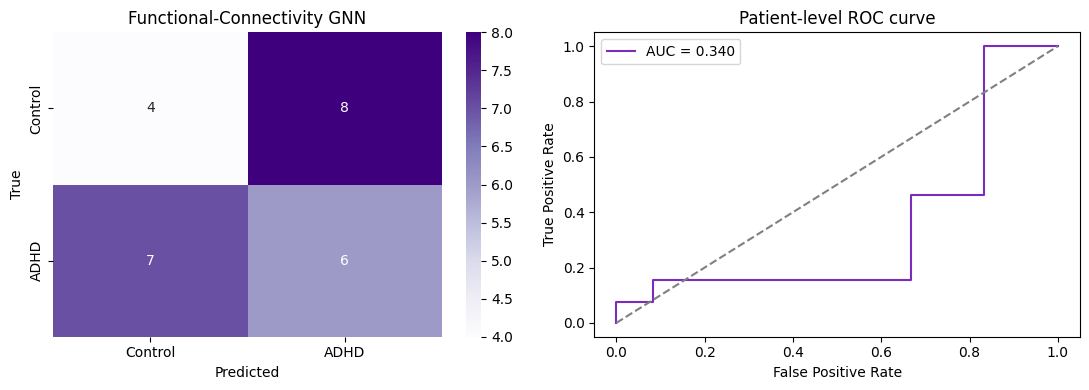

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=axes[0],
    xticklabels=["Control", "ADHD"],
    yticklabels=["Control", "ADHD"]
)

axes[0].set_title(
    "Functional-Connectivity GNN"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

axes[1].plot(
    fpr,
    tpr,
    color="#7B2CBF",
    label=(
        f"AUC = "
        f"{test_metrics['roc_auc']:.3f}"
    )
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

axes[1].set_title("Patient-level ROC curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The GNN correctly classified 4 of 12 Control patients and 6 of 13 ADHD patients. It produced 8 false-positive ADHD predictions and missed 7 ADHD patients.

The model predicted both classes, so it did not completely collapse into predicting one label. However, its decision boundary failed to separate the two diagnostic groups.  

## ROC-AUC Interpretation

The test ROC-AUC of 0.340 is below the random-reference value of 0.500. This means that the GNN frequently assigned higher ADHD probabilities to Control patients than to actual ADHD patients.

Although reversing the probabilities would mathematically produce an AUC of approximately 0.660, performing such a reversal after observing the test labels would not be a valid model correction. The below-chance AUC instead demonstrates unstable and poorly generalizing probability rankings.  

## 14. Compare the Three Approaches

All three models use the same seed and patient-level split. The comparison examines waveform-based MIL, self-supervised MIL and functional-connectivity graph learning.

In [17]:
original_mil_metrics = {
    "accuracy": 0.720,
    "balanced_accuracy": 0.724,
    "precision": 0.800,
    "recall": 0.615,
    "specificity": 0.833,
    "f1": 0.696,
    "roc_auc": 0.737,
    "mcc": 0.458
}

ssl_mil_metrics = {
    "accuracy": 0.760,
    "balanced_accuracy": 0.756,
    "precision": 0.733,
    "recall": 0.846,
    "specificity": 0.667,
    "f1": 0.786,
    "roc_auc": 0.737,
    "mcc": 0.523
}

comparison_df = pd.DataFrame(
    [
        original_mil_metrics,
        ssl_mil_metrics,
        test_metrics
    ],
    index=[
        "Original Dual-View MIL",
        "Cross-View SSL + MIL",
        "Functional-Connectivity GNN"
    ]
)

display(comparison_df.round(3))

,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,mcc
Original Dual-View MIL,0.72,0.724,0.800,0.615,0.833,0.696,0.737,0.458
Cross-View SSL + MIL,0.76,0.756,0.733,0.846,0.667,0.786,0.737,0.523
Functional-Connectivity GNN,0.40,0.397,0.429,0.462,0.333,0.444,0.340,-0.206


## Comparison With Epoch-Based Models

The original Dual-View MIL and Cross-View SSL models both achieved a test ROC-AUC of 0.737, while the graph model achieved 0.340.

The previous models preserved individual EEG epochs and learned patient predictions from temporal segments. In contrast, the graph approach averaged all epochs into one representation, likely removing useful within-patient variability.

Therefore, the poor result appears to be caused primarily by the simplified graph-construction method rather than by graph learning in general.

## 15. Channel Attention

Average node attention shows which EEG channels received the most emphasis across test-patient predictions.

Attention should be treated as a model interpretation, not proof that a channel causes ADHD.

,channel,mean_attention
0,C3,0.0781
1,Cz,0.0763
2,C4,0.0759
3,F3,0.0744
4,F4,0.0731
5,Fz,0.0711
6,F7,0.0677
7,Fp1,0.0671
8,P3,0.0655
9,F8,0.0646


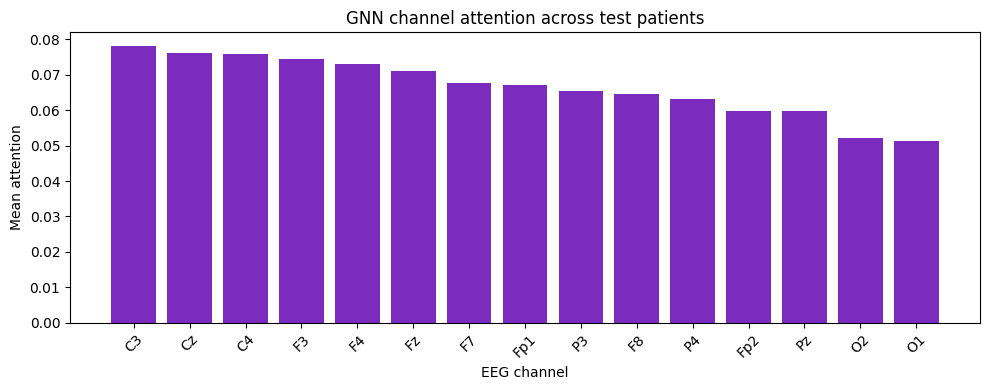

In [18]:
mean_channel_attention = (
    test_attention.mean(axis=0)
)

channel_importance_df = (
    pd.DataFrame({
        "channel": channel_names,
        "mean_attention":
            mean_channel_attention
    })
    .sort_values(
        "mean_attention",
        ascending=False
    )
    .reset_index(drop=True)
)

display(channel_importance_df.round(4))

plot_order = np.argsort(
    mean_channel_attention
)[::-1]

plt.figure(figsize=(10, 4))

plt.bar(
    np.asarray(channel_names)[plot_order],
    mean_channel_attention[plot_order],
    color="#7B2CBF"
)

plt.xlabel("EEG channel")
plt.ylabel("Mean attention")
plt.title(
    "GNN channel attention across test patients"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Channel-Attention Interpretation

The highest average attention was assigned to C3, Cz and C4. However, the attention values were close to the uniform value of 0.0667, indicating weak differentiation between channels.

Small group differences appeared at channels such as Cz, Fp2, F8, P4 and O2. Because the classifier performed poorly, these differences should not be interpreted as reliable ADHD biomarkers.

## 16. ADHD and Control Channel Attention

Group-level attention is compared to examine whether the model emphasizes different channels for ADHD and Control patients.

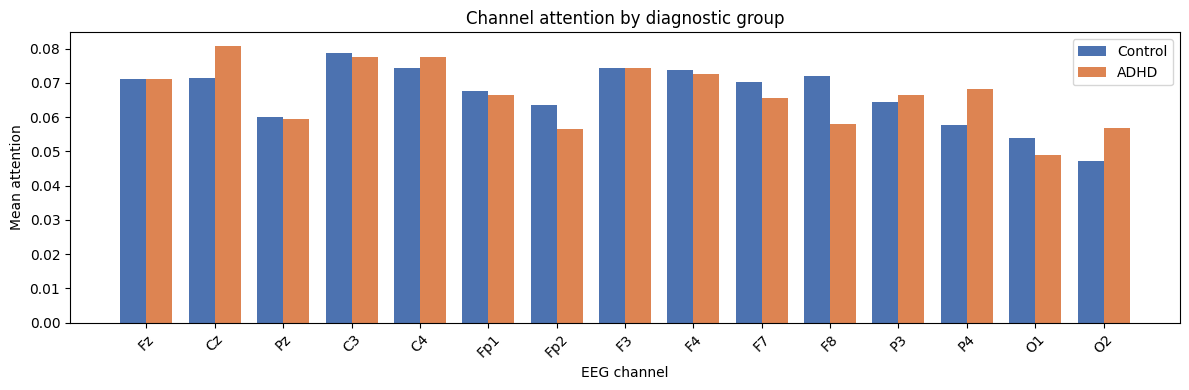

In [19]:
control_attention = test_attention[
    y_test == 0
].mean(axis=0)

adhd_attention = test_attention[
    y_test == 1
].mean(axis=0)

x_positions = np.arange(
    len(channel_names)
)

bar_width = 0.38

plt.figure(figsize=(12, 4))

plt.bar(
    x_positions - bar_width / 2,
    control_attention,
    width=bar_width,
    label="Control",
    color="#4C72B0"
)

plt.bar(
    x_positions + bar_width / 2,
    adhd_attention,
    width=bar_width,
    label="ADHD",
    color="#DD8452"
)

plt.xticks(
    x_positions,
    channel_names,
    rotation=45
)

plt.xlabel("EEG channel")
plt.ylabel("Mean attention")
plt.title(
    "Channel attention by diagnostic group"
)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Save the Graph Model and Results

The trained GNN, feature-scaling information, predictions and metrics are saved separately from the previous experiments.

In [20]:
output_dir = Path("/kaggle/working")

torch.save(
    {
        "model_state_dict":
            gnn_model.state_dict(),
        "input_features": INPUT_FEATURES,
        "hidden_features": 64,
        "channel_names": channel_names,
        "scaler_mean":
            feature_scaler.mean_,
        "scaler_scale":
            feature_scaler.scale_,
        "seed": SEED,
        "best_epoch": best_epoch,
        "best_validation_auc":
            best_val_auc
    },
    output_dir
    / "functional_connectivity_gnn.pt"
)

gnn_predictions_df = pd.DataFrame({
    "patient_id": test_patient_ids,
    "y_true": y_test,
    "adhd_probability":
        test_probabilities,
    "y_pred": test_predictions
})

gnn_predictions_df.to_csv(
    output_dir
    / "gnn_patient_predictions.csv",
    index=False
)

gnn_metrics_df.to_csv(
    output_dir
    / "gnn_test_metrics.csv"
)

history_df.to_csv(
    output_dir
    / "gnn_training_history.csv",
    index=False
)

channel_importance_df.to_csv(
    output_dir
    / "gnn_channel_attention.csv",
    index=False
)

comparison_df.to_csv(
    output_dir
    / "three_model_comparison.csv"
)

print(
    "Graph model and results saved to "
    "/kaggle/working"
)

Graph model and results saved to /kaggle/working


## Experiment Conclusion

The Functional-Connectivity GNN did not successfully generalize to unseen patients. Averaging all epochs, using absolute broadband correlation and constructing a relatively dense graph likely removed important temporal and frequency-specific information.

This negative result does not demonstrate that EEG graph models are ineffective. Instead, it shows that successful graph learning requires a more informative connectivity definition, such as frequency-specific coherence or phase-lag connectivity, and possibly dynamic graphs constructed from individual epochs.